In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tapas_gmm_modified.policy.models.tpgmm import (
    ReconstructionStrategy, 
    FittingStage,
    InitStrategy,

)
from tapas_gmm_modified.dataset.demos import Demos
from tapas_gmm_modified.viz.gmm import plot_hmm_transition_matrix

np.set_printoptions(precision=2)

plt.style.use('default')

from matplotlib import rc
rc('animation', html='jshtml')

2026-07-07 01:23:07.043 | INFO     |  Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
from heca.agents.experts.tapas import TapasAgent
from conf.agents.experts.tapas import unlock_left as agent_cfg
agent = TapasAgent.get(agent_cfg, auto_load=True)
print(agent_cfg.policy.model.frame_selection.gt_frames)
selections = [0, 1, 3, 4, 5]

2026-07-07 01:23:14.161 | INFO     | heca.misc.logger:info:30 - Running on cpu


/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/jangruhnert/miniconda3/envs/hecarim/lib/python3.10/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


2026-07-07 01:23:15.770 | INFO     | heca.misc.logger:info:30 - Loading <class 'heca.agents.experts.tapas.TapasAgent'> from /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/unlock_left_button
2026-07-07 01:23:15.770 | INFO     | tapas_gmm_modified.utils.logging:wrapper:67 - Initializing Policy:
2026-07-07 01:23:15.770 | INFO     | tapas_gmm_modified.encoder:get_image_encoder_class:62 - No encoder config provided. Using None.
2026-07-07 01:23:15.771 | WARNING  | heca.misc.logger:warning:26 - No tapas policy found at given path: /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/unlock_left_button/policy_gt.pt
GMMPolicy(
  (obs_encoder): ObservationEncoder()
)
[[0, 3], [3, 7]]


In [3]:
observations = agent.load_demos(selections)

# Debug: check shapes of object_poses
for i, obs in enumerate(observations):
    print(f"\n--- Trajectory {i} ---")
    print("ee_pose shape:", obs.ee_pose.shape)
    for key, val in obs.object_poses.items():
        print(f"  {key}: {val.shape}")
    print(f"  n_obj_keys: {len(obs.object_poses.keys())}")

demos = Demos(
    observations,
    add_init_ee_pose_as_frame=True,
    add_world_frame=False,
    frames_from_keypoints=False,
    kp_indeces=None,
    enforce_z_up=False,
    modulo_object_z_rotation=False,
    make_quats_continuous=True,
)  # type: ignore
print("n_trajs", demos.n_trajs)
print("n_frames", demos.n_frames)
demos.frame_names


--- Trajectory 0 ---
ee_pose shape: torch.Size([34, 7])
  block_0: torch.Size([34, 7])
  button_1: torch.Size([34, 7])
  button_0: torch.Size([34, 7])
  window_handle: torch.Size([34, 7])
  drawer_handle: torch.Size([34, 7])
  block_0_target: torch.Size([34, 7])
  ee_target: torch.Size([34, 7])
  n_obj_keys: 7

--- Trajectory 1 ---
ee_pose shape: torch.Size([38, 7])
  block_0: torch.Size([38, 7])
  button_1: torch.Size([38, 7])
  button_0: torch.Size([38, 7])
  window_handle: torch.Size([38, 7])
  drawer_handle: torch.Size([38, 7])
  block_0_target: torch.Size([38, 7])
  ee_target: torch.Size([38, 7])
  n_obj_keys: 7

--- Trajectory 2 ---
ee_pose shape: torch.Size([41, 7])
  block_0: torch.Size([41, 7])
  button_1: torch.Size([41, 7])
  button_0: torch.Size([41, 7])
  window_handle: torch.Size([41, 7])
  drawer_handle: torch.Size([41, 7])
  block_0_target: torch.Size([41, 7])
  ee_target: torch.Size([41, 7])
  n_obj_keys: 7

--- Trajectory 3 ---
ee_pose shape: torch.Size([37, 7])
  bl

('ee_init',
 'block_0',
 'button_1',
 'button_0',
 'window_handle',
 'drawer_handle',
 'block_0_target',
 'ee_target')

2026-07-07 01:24:26.794 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-07-07 01:24:26.794 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 01:24:26.794 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_segment_and_frame_select:2860 - Segmenting trajectories


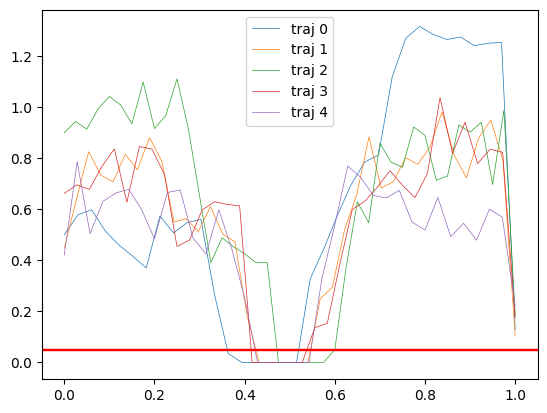

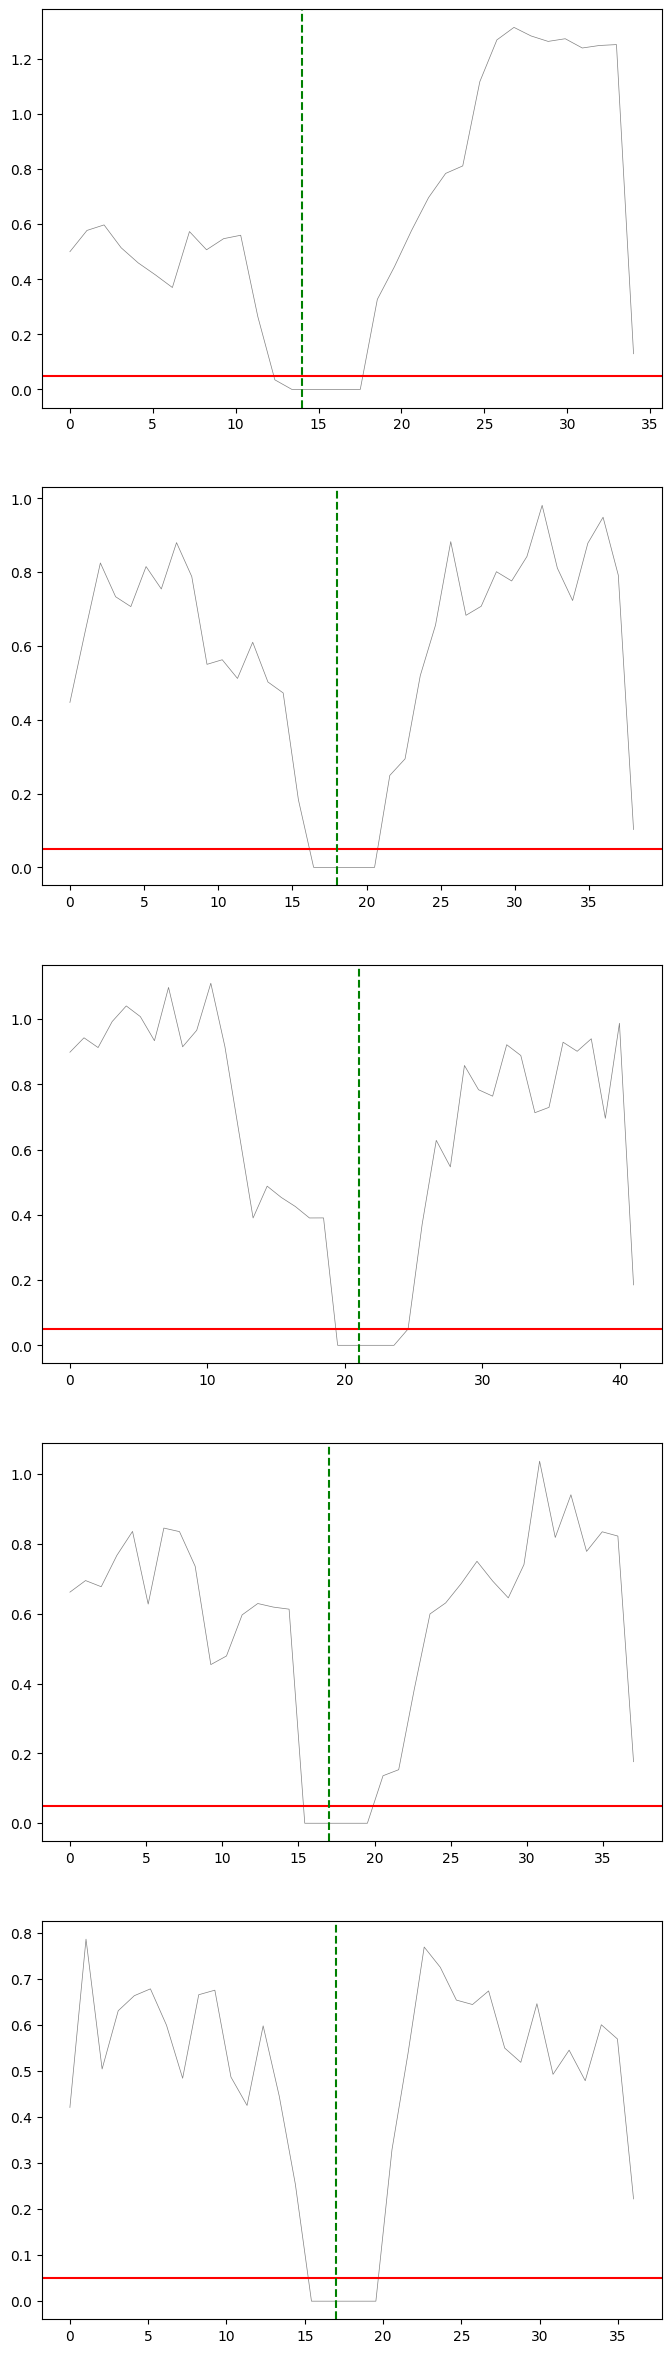

2026-07-07 01:24:27.168 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2697 - Creating segement of demos.
2026-07-07 01:24:27.169 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 17 using strategy mean-length.
2026-07-07 01:24:27.170 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2697 - Creating segement of demos.
2026-07-07 01:24:27.171 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 19 using strategy mean-length.
2026-07-07 01:24:27.171 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_segment_and_frame_select:2865 - ... created 2 segments
2026-07-07 01:24:27.171 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 1/8
2026-07-07 01:24:27.171 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 01:24:27.171 | INFO     | tapas_gmm_modified.dataset.demos:subsample_t

Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2026-07-07 01:24:27.224 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 2/8
2026-07-07 01:24:27.224 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 01:24:27.225 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 17 using strategy mean-length.
2026-07-07 01:24:27.228 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R1
2026-07-07 01:24:27.228 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 01:24:27.228 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 01:24:27.228 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2026-07-07 01:24:27.288 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_frames:3043 - Fitting candidate frame 3/8
2026-07-07 01:24:27.289 | INFO     | tapas_gmm_modified.dataset.demos:__init__:2470 - Creating partial frame view of demos.
2026-07-07 01:24:27.289 | INFO     | tapas_gmm_modified.dataset.demos:subsample_to_common_length:609 - Subsampling to length 17 using strategy mean-length.
2026-07-07 01:24:27.292 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R1
2026-07-07 01:24:27.292 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 01:24:27.292 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 01:24:27.292 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


...

2026-07-07 01:24:28.385 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R3 x QUAT x R1
2026-07-07 01:24:28.388 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 9
2026-07-07 01:24:28.388 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 01:24:28.388 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/9 [00:00<?, ?it/s]

2026-07-07 01:24:28.490 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_setup_manifold:735 - Manifold: TIME x R3 x QUAT x R3 x QUAT x R1
2026-07-07 01:24:28.490 | INFO     | riepybdlib.statistics:set_n_components:779 - Changing number of components to 10
2026-07-07 01:24:28.490 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [INIT]
2026-07-07 01:24:28.490 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_init:1195 - Model init ...


Time-based init:   0%|          | 0/10 [00:00<?, ?it/s]

((array([[6.41e+012, 9.87e+012, 2.95e+009, 1.54e+009, 6.15e+000, 9.97e-013,
          7.34e-026, 1.21e-035, 1.23e-036, 2.10e-044, 2.71e-054, 8.11e-063,
          1.91e-067, 1.72e-075, 7.89e-080, 7.10e-085, 7.95e-092, 1.77e+013,
          1.12e+013, 6.63e+011, 5.57e+007, 8.51e+002, 8.83e-004, 6.00e-012,
          2.04e-025, 6.14e-037, 1.23e-060, 9.22e-072, 4.45e-083, 1.90e-094,
          1.25e-106, 6.49e-119, 3.82e-131, 3.11e-136, 1.05e+013, 1.41e+013,
          7.07e+011, 1.96e+004, 8.90e-002, 3.02e-008, 1.68e-030, 8.36e-039,
          2.80e-049, 3.66e-064, 2.84e-077, 5.79e-098, 2.45e-103, 5.57e-118,
          1.72e-142, 2.93e-157, 3.61e-162, 7.46e+012, 1.06e+013, 2.73e+011,
          1.16e+008, 1.23e+002, 2.30e-006, 7.59e-016, 1.11e-029, 3.49e-040,
          1.49e-049, 1.16e-060, 4.26e-075, 2.34e-090, 5.84e-109, 4.62e-128,
          1.07e-142, 1.94e-149, 1.04e+013, 6.87e+012, 5.03e+009, 1.46e+006,
          1.05e+001, 4.70e-006, 4.34e-015, 7.84e-028, 1.11e-038, 1.26e-048,
          6.

In [4]:
agent.model.fit_trajectories(demos, fix_frames=True,
                       init_strategy=InitStrategy.TIME_BASED,
                       fitting_actions=(FittingStage.INIT,))


2026-07-07 01:24:41.706 | INFO     | tapas_gmm_modified.policy.models.tpgmm:plot_model:3856 - Did not specify time_based, deciding automatically.
2026-07-07 01:24:41.771 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:24:41.772 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:24:41.772 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:24:41.772 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:24:41.772 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:24:41.772 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:24:41.772 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:24:41.772 | WARNING  | tapas_gmm_modified.viz.gmm

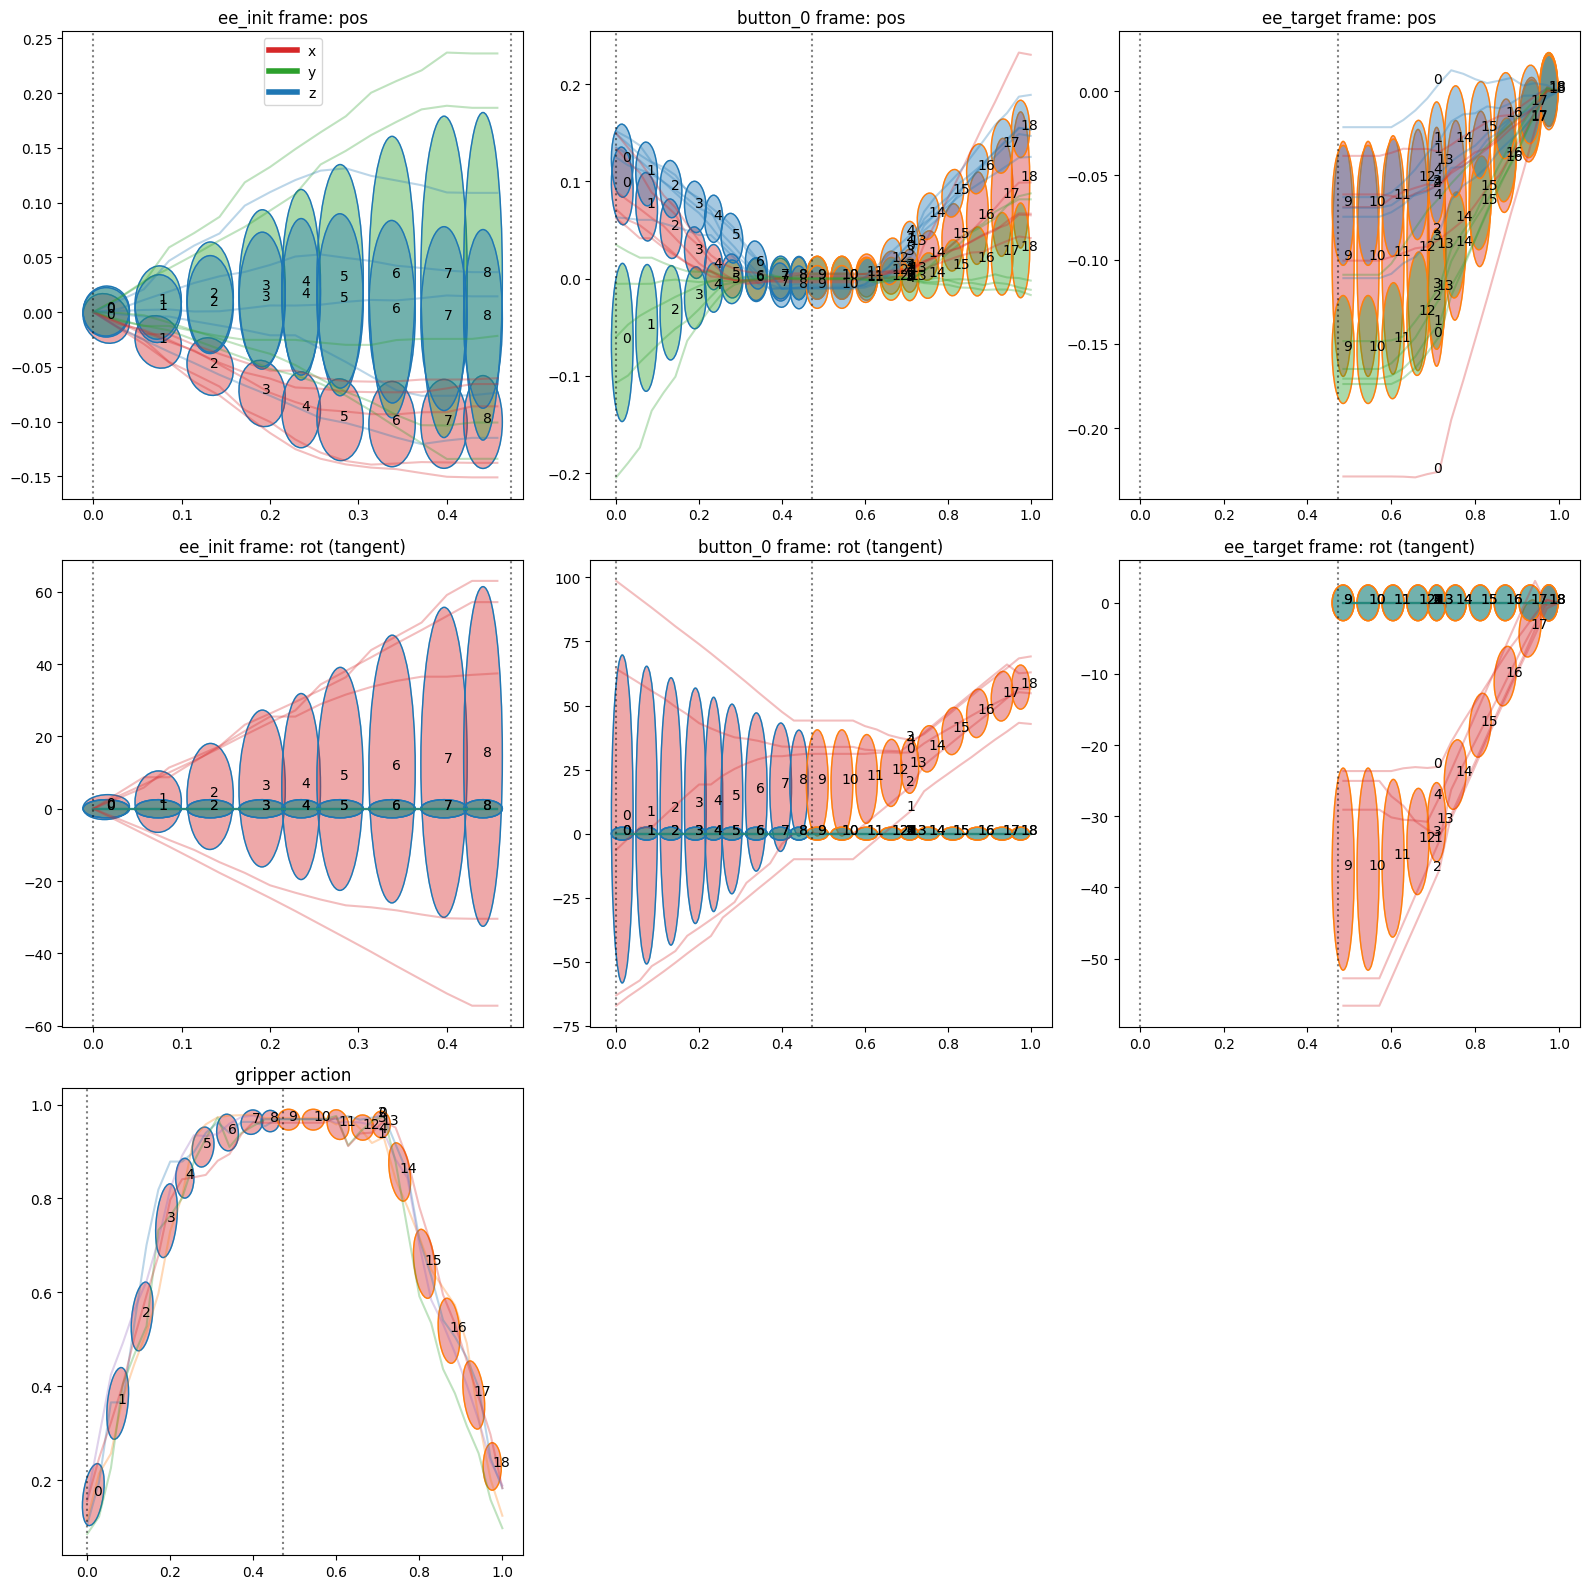

In [5]:
agent.model.plot_model(scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False)


In [6]:
agent.model.fit_trajectories(demos, fix_frames=True, fitting_actions=(FittingStage.EM_HMM, ))


2026-07-07 01:25:08.141 | INFO     | tapas_gmm_modified.policy.models.tpgmm:fit_trajectories:2740 - Fitting AutoTPGMM
2026-07-07 01:25:08.141 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]


Fitting segments:   0%|          | 0/2 [00:00<?, ?it/s]

2026-07-07 01:25:08.144 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]
2026-07-07 01:25:08.144 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_hmm:1296 - HMM EM ...
2026-07-07 01:25:08.147 | INFO     | riepybdlib.statistics:trans:1710 - HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-07-07 01:25:08.166 | INFO     | riepybdlib.statistics:init_priors:1698 - HMM init priors not defined, initializing to uniform
2026-07-07 01:25:13.786 | INFO     | riepybdlib.statistics:em:2249 - HMM EM converged
2026-07-07 01:25:13.815 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_select_fitting_actions:1088 - Performing fitting actions: [EM_HMM]
2026-07-07 01:25:13.815 | INFO     | tapas_gmm_modified.policy.models.tpgmm:_fit_rbd_hmm:1296 - HMM EM ...
2026-07-07 01:25:13.818 | INFO     | riepybdlib.statistics:trans:1710 - HMM transition matrix not defined, initializing to uniform


HMM EM:   0%|          | 0/50 [00:00<?, ?it/s]

2026-07-07 01:25:13.834 | INFO     | riepybdlib.statistics:init_priors:1698 - HMM init priors not defined, initializing to uniform
2026-07-07 01:25:20.152 | INFO     | riepybdlib.statistics:em:2249 - HMM EM converged


((array([[1.00e+000, 9.36e-001, 1.29e-003, 7.03e-013, 8.17e-035, 3.09e-070,
          5.33e-122, 2.53e-191, 1.46e-277, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 1.00e+000,
          9.66e-001, 2.50e-002, 2.67e-008, 7.22e-022, 1.09e-048, 3.48e-093,
          7.34e-160, 1.42e-249, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 1.00e+000, 9.85e-001,
          4.37e-002, 2.12e-012, 1.62e-034, 1.80e-072, 2.96e-136, 1.36e-224,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 1.00e+000, 9.96e-001, 5.82e-003,
          3.47e-013, 4.12e-037, 8.37e-079, 9.97e-143, 4.49e-233, 0.00e+000,
          0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000, 0.00e+000,
          0.00e+000, 0.00e+000, 1.00e+000, 8.94e-001, 1.91e-004, 2.38e-016,
          4.12e-040, 1.21e-079, 7.28e-138, 1.49e-216, 0.00e+000, 0.00e+000,
          0.

2026-07-07 01:25:23.356 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:25:23.356 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:25:23.357 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:25:23.357 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:25:23.357 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:25:23.357 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:25:23.357 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:25:23.357 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippig NaN Gaussians.
2026-07-07 01:25:23.357 | WARNING  | tapas_gmm_modified.viz.gmm:plot_gmm_time_based:538 - Skippi

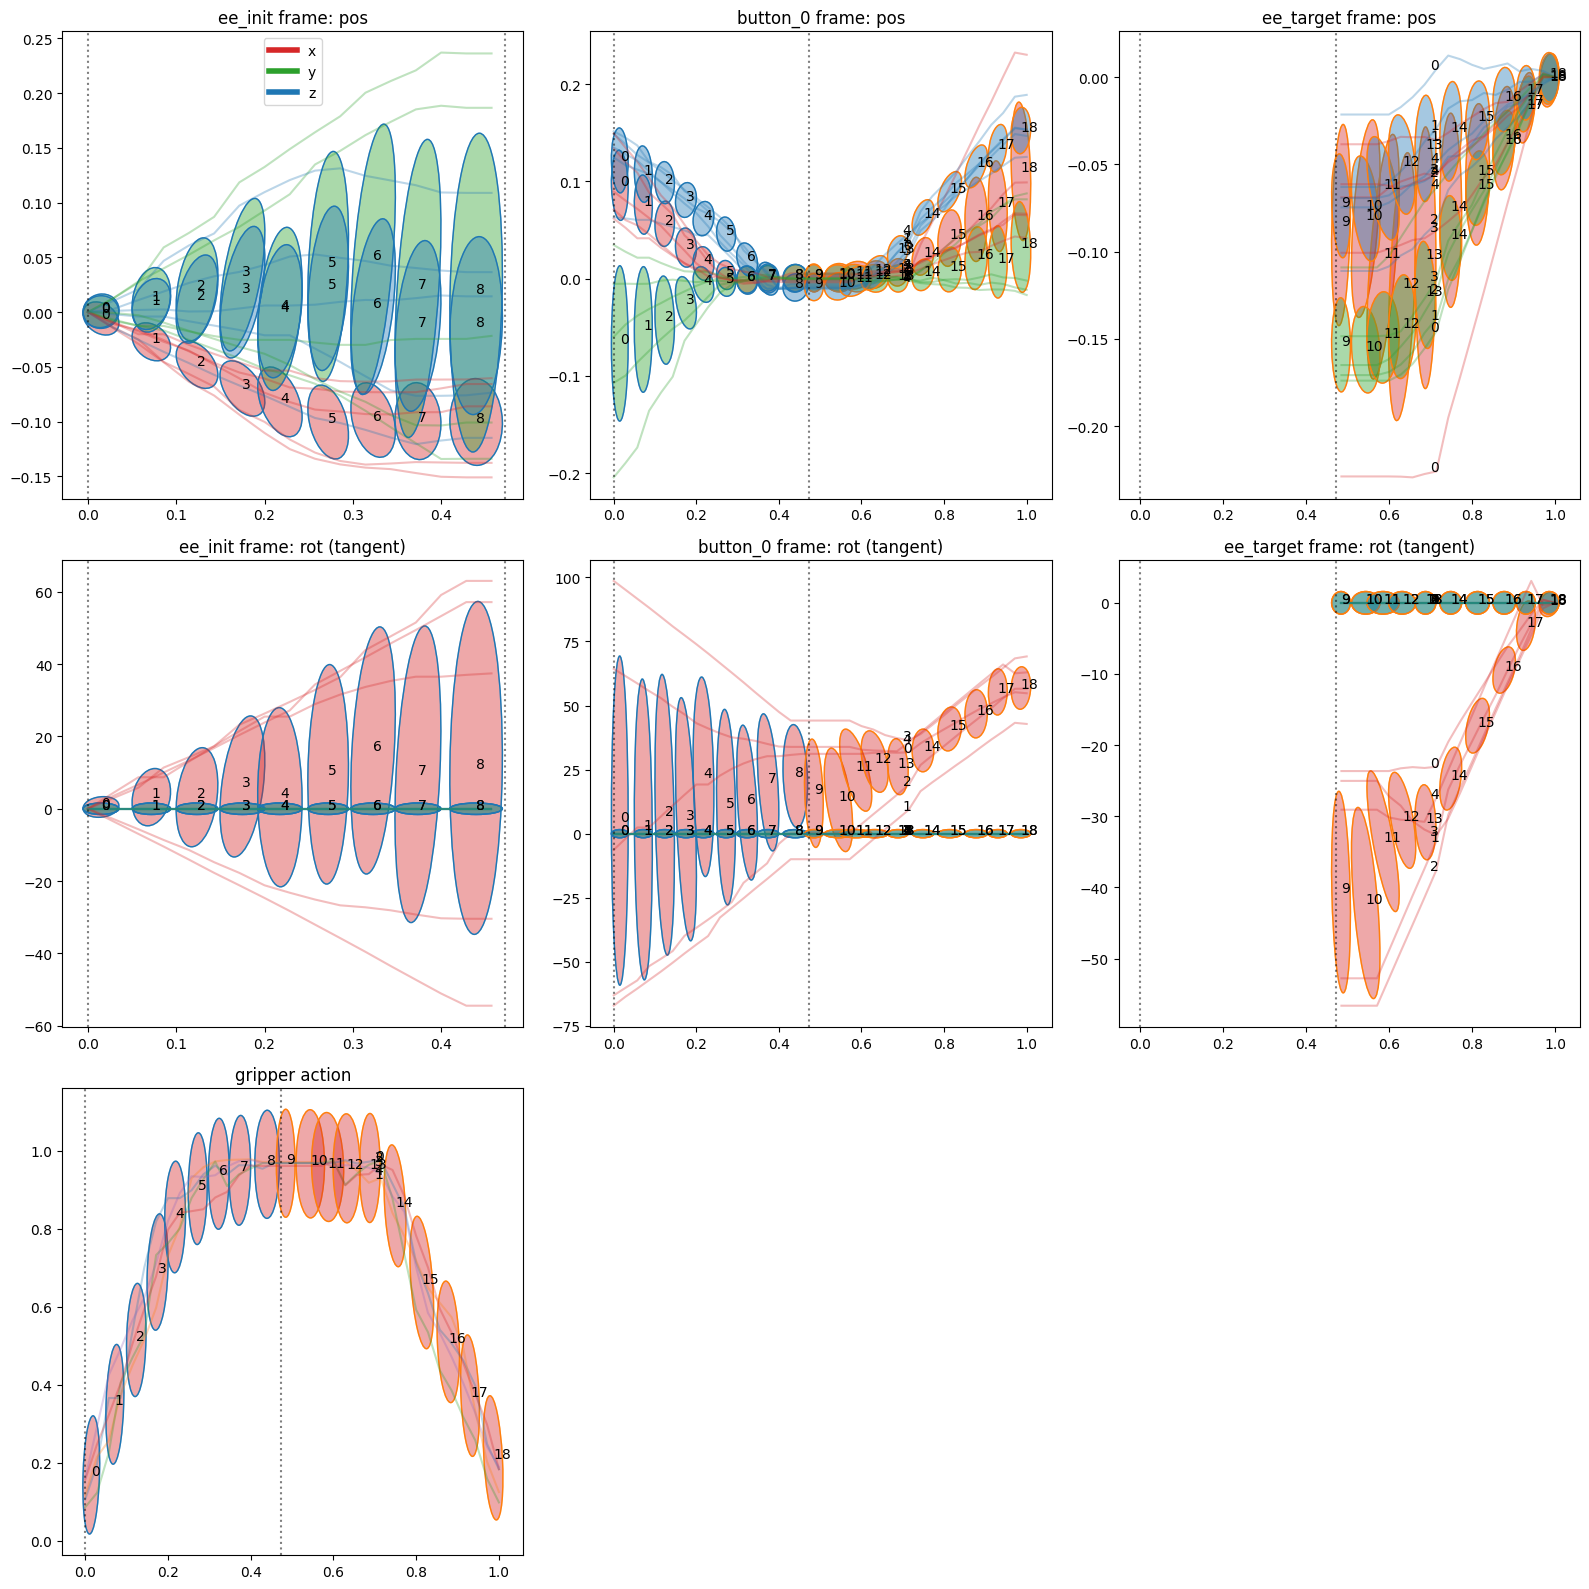

In [7]:
agent.model.plot_model(
    scatter=True, annotate_gaussians=True, annotate_trajs=True, mean_as_base=False, time_based=True,
)

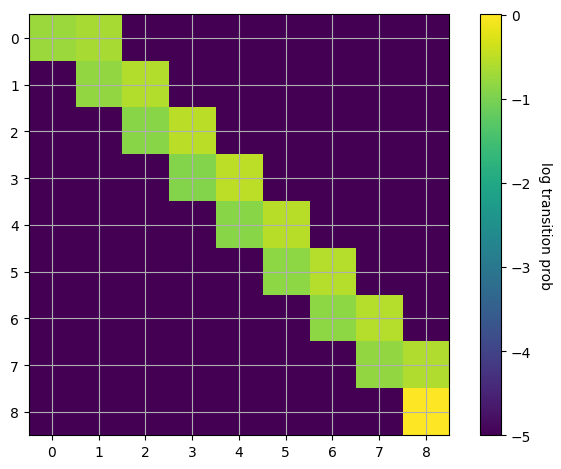

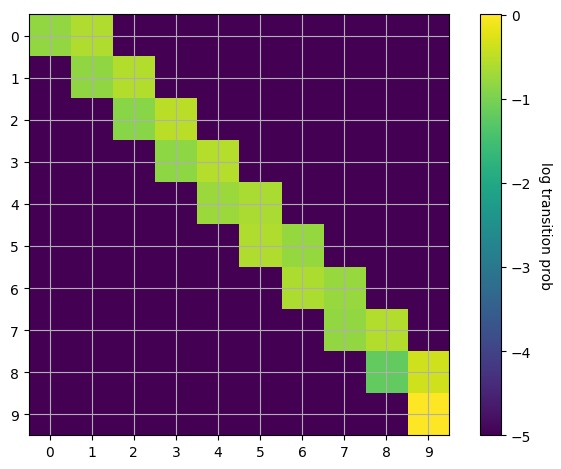

In [8]:
agent.model.plot_hmm_transition_matrix()

In [9]:
agent.save()

2026-07-07 01:25:54.681 | INFO     | heca.misc.logger:info:30 - Saving <class 'heca.agents.experts.tapas.TapasAgent'> to /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/unlock_left_button
2026-07-07 01:25:54.681 | INFO     | heca.misc.logger:info:30 - Saving tapas policy to: /home/jangruhnert/Documents/GitHub/master-project/data/agents/tapas/unlock_left_button/policy_gt.pt
2026-07-07 01:25:54.681 | INFO     | tapas_gmm_modified.policy.models.tpgmm:to_disk:2617 - Saving model:


In [ ]:
seg_local_marginals, seg_trans_marginals, seg_trans_marg_container, seg_joint_models, cascaded_hmms, (reconstructions, original_trajectories, extras) = agent.model.reconstruct(
    strategy=ReconstructionStrategy.GMR,
    use_ss=False)


In [ ]:
for cascaded_hmm in cascaded_hmms:
    plot_hmm_transition_matrix(cascaded_hmm)

In [ ]:
agent.model.plot_reconstructions(
    seg_trans_marg_container,
    cascaded_hmms,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=True,
    equal_aspect=False,
    per_segment=False,
)

In [ ]:
agent.model.plot_reconstructions(
    seg_trans_marginals,
    seg_joint_models,
    reconstructions,
    original_trajectories,
    plot_trajectories=True,
    plot_reconstructions=True,
    plot_gaussians=True,
    time_based=False,
    equal_aspect=True,
    per_segment=False,
)